In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
from langchain.chat_models import init_chat_model
from langchain_groq import ChatGroq

groq_api_key = os.getenv("GROQ_API_KEY")

model = init_chat_model("openai/gpt-oss-120b", model_provider="GROQ")
model

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001850A2B0DA0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001850A413DA0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [4]:
##Chat bot with tool
from langchain_tavily import TavilySearch
tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norwegian Cr

In [5]:
# Custom Function
def multiply(a: int, b: int) -> int:
    """
    Multiple a and b

    Args:
        a: a is first int
        b: b is second int

    Returns:
        int : output in result

    """
    return a * b


tools = [tool, multiply]
llm_with_tools = model.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001850A2B0DA0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001850A413DA0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, an

In [6]:
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph

class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

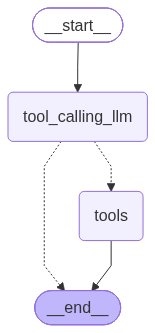

In [ ]:
##Stategraph

from langgraph.graph import StateGraph, START, END

from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display


## Node Defination
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


##Graph
builder = StateGraph(State)
## Add nodes 
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

##Add edges

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    ##1. If the latest message(result) is from assistant is the tool call -> tool condition routes to tools
    ##2. If the latest message (Result) is from assistant is not a tool call -> tool condition routes to END
    tools_condition,
)

builder.add_edge("tools", END)

##Compile the graph
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
#response = graph.invoke({"messages": "What is the recent AI news?"})
value = graph.invoke({"messages": "what is the Value of 999 multiply 679"})

In [9]:
#response
value

{'messages': [HumanMessage(content='what is the Value of 999 multiply 679', additional_kwargs={}, response_metadata={}, id='7cd1f825-3763-4b46-a0a2-d2e6a6b36cfe'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to compute 999 * 679. Use multiply function.', 'tool_calls': [{'id': 'fc_a620a9eb-31a1-4c15-88e3-92d590140c1c', 'function': {'arguments': '{"a":999,"b":679}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 356, 'total_tokens': 404, 'completion_time': 0.101723915, 'completion_tokens_details': {'reasoning_tokens': 15}, 'prompt_time': 0.017290444, 'prompt_tokens_details': None, 'queue_time': 0.354865773, 'total_time': 0.119014359}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_8ea50c0161', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a09037-1df9-7412-9a68-b65ec5bc854c-0', tool_calls=[{'name': '

In [10]:
value["messages"][-1].content

'678321'

In [11]:
for m in value["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the Value of 999 multiply 679
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_a620a9eb-31a1-4c15-88e3-92d590140c1c)
 Call ID: fc_a620a9eb-31a1-4c15-88e3-92d590140c1c
  Args:
    a: 999
    b: 679
================================= Tool Message =================================
Name: multiply

678321


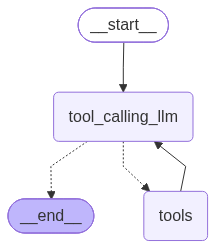

In [12]:
##React Agent Archetecture

##Stategraph

from langgraph.graph import StateGraph, START, END

from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display


## Node Defination
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


##Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

##Add edges

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    ##1. If the latest message(result) is from assistant is the tool call -> tool condition routes to tools
    ##2. If the latest message (Result) is from assistant is not a tool call -> tool condition routes to END
    tools_condition,
)

builder.add_edge("tools", "tool_calling_llm")

##Compile the graph
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
value = graph.invoke({"messages": "Hey what is my name"})

for m in value["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hey what is my name
================================== Ai Message ==================================

I’m sorry, but I don’t have any information about your name. If you’d like me to address you personally, just let me know what you’d like to be called!


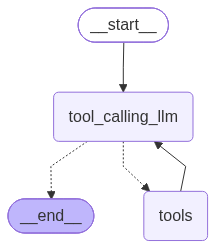

In [14]:
##Memery Saver

##Adding memory in Agentic graph
##React Agent Archetecture

##Stategraph

from langgraph.graph import StateGraph, START, END

from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()


## Node Defination
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


##Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

##Add edges

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    ##1. If the latest message(result) is from assistant is the tool call -> tool condition routes to tools
    ##2. If the latest message (Result) is from assistant is not a tool call -> tool condition routes to END
    tools_condition,
)

builder.add_edge("tools", "tool_calling_llm")

##Compile the graph
graph = builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
config={"configurable":{"thread_id":"2"}}
value = graph.invoke({"messages": "Hey do you remember my name"}, config=config)

for m in value["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hey do you remember my name
================================== Ai Message ==================================

I’m afraid I don’t have your name on file. Could you remind me what you’d like me to call you?


In [17]:
##Streaming Techniques in langgraph
config = {"configurable": {"thread_id": "4"}}
value = graph.invoke({"messages": "Hello what is my name ?"}, config=config, stream_mode="value")